Available Job Roles:
1. Backend Developer
2. IT Support Specialist
3. Frontend Developer
4. AI Engineer
5. Project Manager
6. Web Developer
7. Database Administrator
8. Product Manager
9. Machine Learning Engineer
10. Full Stack Developer
11. Systems Analyst
12. DevOps Engineer
13. Data Scientist
14. Cloud Engineer
15. Cybersecurity Analyst


c:\Users\Gnanendhiran V\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
C:\Users\Gnanendhiran V\AppData\Local\Temp\ipykernel_16872\477202905.py:101: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='ML_Score_Percent', y='name', data=top_resumes, palette='viridis', label='ML Score')


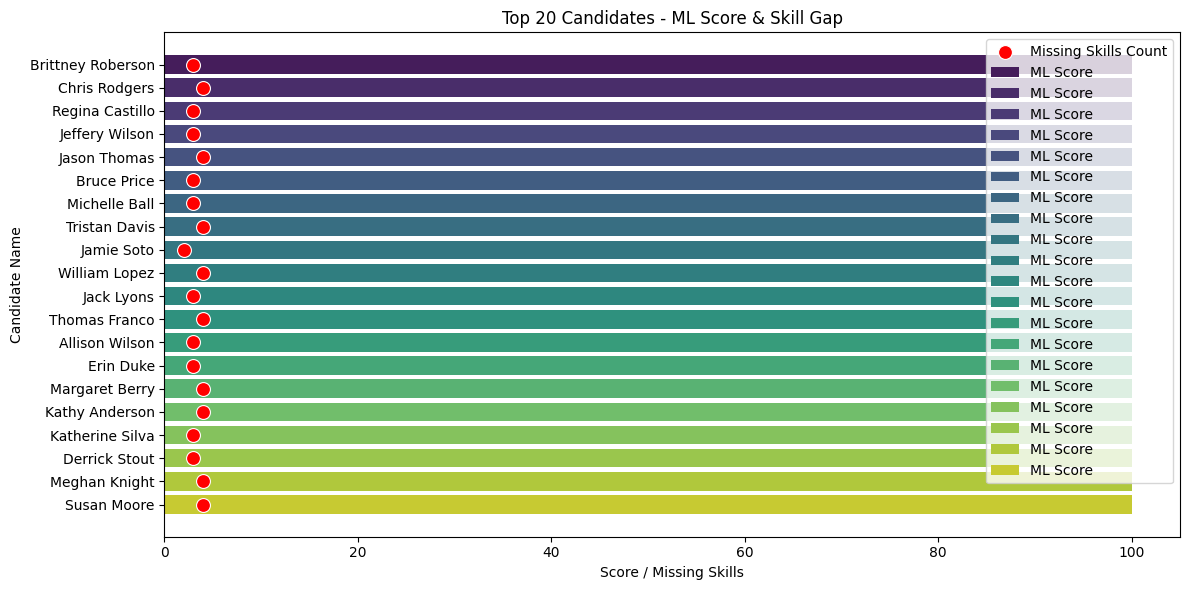

ModuleNotFoundError: No module named 'openpyxl'

In [2]:
# Step 0: Install packages
# !pip install pandas numpy scikit-learn sentence-transformers matplotlib seaborn openpyxl

# Step 1: Import Libraries
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Load Data
url = "https://raw.githubusercontent.com/Gnanendhiran/ML_Project/main/job_descriptions_1000.csv"
jobs = pd.read_csv(url)
resumes_url = "https://raw.githubusercontent.com/Gnanendhiran/ML_Project/main/resumes_dataset_2000.csv"
resumes = pd.read_csv(resumes_url)

# Step 3: Display all job roles vertically
print("Available Job Roles:")
for idx, role in enumerate(jobs['title'].drop_duplicates(), 1):
    print(f"{idx}. {role}")

# Step 4: Get user input
job_title_input = input("\nEnter the Job Role to rank candidates: ").strip()
job_row = jobs[jobs['title'].str.lower() == job_title_input.lower()]
if job_row.empty:
    raise ValueError(f"No job found with role '{job_title_input}'")
job = job_row.iloc[0]

# Step 5: Extract job attributes
required_skills = [s.strip() for s in str(job['required_skills']).split(",") if s.strip()]
preferred_edu = job.get('preferred_education', 'B.Tech')
min_exp = job.get('min_experience', 1)

# Step 6: Preprocess resumes
resumes['Skills_List'] = resumes['skills'].apply(lambda x: [s.strip() for s in str(x).split(",") if s.strip()])

# Step 7: Compute embeddings & Cosine Similarity
model = SentenceTransformer('all-MiniLM-L6-v2')
jd_text = f"{job['title']} {job['required_skills']} {job['preferred_education']}"
jd_emb = model.encode([jd_text])

resumes['Resume_Embedding'] = resumes['skills'].apply(lambda x: model.encode([str(x)])[0])
resumes['Cosine_Sim'] = resumes['Resume_Embedding'].apply(lambda x: cosine_similarity([x], [jd_emb[0]])[0][0])

# Step 8: Skill Match Ratio
def skill_match_ratio(candidate_skills, required_skills):
    matched = len(set([s.lower() for s in candidate_skills]) & set([s.lower() for s in required_skills]))
    return matched / len(required_skills) if required_skills else 0

resumes['Skill_Match'] = resumes['Skills_List'].apply(lambda x: skill_match_ratio(x, required_skills))

# Step 9: Experience & Education Score
resumes['experience_years'] = resumes['experience_years'].fillna(0)
resumes['experience_score'] = resumes['experience_years'].apply(lambda x: min(x / min_exp, 1) if min_exp > 0 else 1)

edu_map = {'B.E':0.5,'B.Tech':0.5,'M.E':0.7,'M.Tech':0.7,'BSc':0.5,'MSc':0.7,'BCA':0.5,'MCA':0.7,'BBA':0.5,'MBA':0.8,'PhD':1.0}
preferred_score = edu_map.get(preferred_edu, 0.5)
resumes['education_score'] = resumes['education'].map(edu_map).fillna(0.3)
resumes['education_score'] = resumes['education_score'].apply(lambda x: 1.0 if x >= preferred_score else x)

# Step 10: Pseudo labels
def pseudo_label(cosine, skill, exp, edu):
    if cosine >= 0.75 and skill >= 0.6 and exp >= 0.5 and edu >= 0.7:
        return 1
    if skill >= 0.7 and edu >= 0.7 and exp < 0.3 and cosine >= 0.65:
        return 1
    if exp >= 0.8 and cosine >= 0.65:
        return 1
    if cosine >= 0.70 and skill >= 0.5:
        return 1
    return 0

resumes['Label'] = resumes.apply(lambda row: pseudo_label(row['Cosine_Sim'], row['Skill_Match'], row['experience_score'], row['education_score']), axis=1)

# Step 11: Train Random Forest Model
features = ['Cosine_Sim','Skill_Match','experience_score','education_score']
X = resumes[features]
y = resumes['Label']

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

resumes['ML_Score'] = rf.predict_proba(X)[:,1]
resumes['ML_Score_Percent'] = resumes['ML_Score']*100

# Step 12: Interactive input for top N candidates
top_n = int(input("\nEnter number of top candidates to display: "))
top_resumes = resumes.sort_values(by='ML_Score', ascending=False).head(top_n)

# Step 13: Skill Gap Analysis
def missing_skills(candidate_skills, required_skills):
    return [skill for skill in required_skills if skill.lower() not in [s.lower() for s in candidate_skills]]

top_resumes['Missing_Skills'] = top_resumes['Skills_List'].apply(lambda x: missing_skills(x, required_skills))
top_resumes['Missing_Skills_Count'] = top_resumes['Missing_Skills'].apply(len)

# Step 14: Combine ML Score & Missing Skills Visualization
plt.figure(figsize=(12,6))
sns.barplot(x='ML_Score_Percent', y='name', data=top_resumes, palette='viridis', label='ML Score')
sns.scatterplot(x='Missing_Skills_Count', y='name', data=top_resumes, color='red', s=100, label='Missing Skills Count')
plt.xlabel("Score / Missing Skills")
plt.ylabel("Candidate Name")
plt.title(f"Top {top_n} Candidates - ML Score & Skill Gap")
plt.legend()
plt.tight_layout()
plt.show()

# Step 15: Export to Excel
output_file = f"Top_{top_n}_Candidates_{job['title'].replace(' ','_')}.xlsx"
top_resumes[['name','email','Cosine_Sim','Skill_Match','experience_score','education_score','ML_Score_Percent','Missing_Skills']].to_excel(output_file, index=False)
print(f"\n✅ Top {top_n} candidates exported to '{output_file}'")

# Step 16: Display Table with highlighted missing skills (simple console version)
print("\n📌 Top Candidates with Missing Skills:")
for idx, row in top_resumes.iterrows():
    print(f"{row['name']} ({row['email']}) - Missing Skills: {', '.join(row['Missing_Skills']) if row['Missing_Skills'] else 'None'}")


In [1]:
import pandas as pd
import numpy as np
from faker import Faker
import random
from datetime import datetime

# -------------------------
# CONFIGURATION
# -------------------------
Faker.seed(42)
random.seed(42)
np.random.seed(42)
fake = Faker()

NUM_JDS = 70000
NUM_RESUMES = 70000

# Expanded to 25 diverse IT roles (for 2025 relevance)
ROLES = [
    "Frontend Developer","Backend Developer","Full Stack Developer","Web Developer",
    "Data Scientist","Data Engineer","Machine Learning Engineer","AI Engineer",
    "Cloud Engineer","DevOps Engineer","Database Administrator","Cybersecurity Analyst",
    "Network Engineer","Mobile App Developer","QA Engineer","UI/UX Designer",
    "Product Manager","Systems Administrator","IT Support Engineer","Business Analyst",
    "Data Analyst","MLOps Engineer","AR/VR Developer","Blockchain Developer","Automation Engineer"
]

LOCATIONS = ["Bangalore","Hyderabad","Pune","Chennai","Mumbai","Delhi","Noida","Gurgaon","Kochi","Ahmedabad"]
EMPLOYMENT_TYPES = ["Full-time","Contract","Internship"]

# Weighted education distribution for IT jobs
EDUCATION_WEIGHTS = {
    "B.Tech": 0.35, "B.E": 0.25, "M.Tech": 0.10, "M.E": 0.07,
    "MCA": 0.08, "BCA": 0.05, "BSc": 0.04, "MSc": 0.03,
    "MBA": 0.02, "PhD": 0.00, "BBA": 0.01
}
EDUCATIONS = list(EDUCATION_WEIGHTS.keys())
EDU_PROBS = list(EDUCATION_WEIGHTS.values())

# Expanded & updated realistic IT skills per role (5–8 core JD skills)
ROLE_SKILLS = {
    "Frontend Developer": ["HTML","CSS","JavaScript","React","Angular","TypeScript","Redux","Bootstrap","REST API"],
    "Backend Developer": ["Java","Spring Boot","Node.js","Express.js","Python","Django","Flask","MySQL","PostgreSQL"],
    "Full Stack Developer": ["React","Node.js","Express","MongoDB","HTML","CSS","JavaScript","TypeScript","AWS"],
    "Web Developer": ["HTML","CSS","JavaScript","Bootstrap","jQuery","PHP","WordPress","MySQL","Responsive Design"],
    "Data Scientist": ["Python","R","Pandas","NumPy","Scikit-learn","TensorFlow","SQL","Data Visualization","Statistics"],
    "Data Engineer": ["Python","SQL","Spark","Airflow","ETL","AWS","Hadoop","Kafka","Data Modeling"],
    "Machine Learning Engineer": ["Python","TensorFlow","PyTorch","Scikit-learn","Docker","AWS","Model Deployment","MLflow"],
    "AI Engineer": ["Python","TensorFlow","PyTorch","NLP","Transformers","LangChain","OpenAI API","Deep Learning"],
    "Cloud Engineer": ["AWS","Azure","GCP","Terraform","Kubernetes","Docker","Linux","CI/CD"],
    "DevOps Engineer": ["Jenkins","GitLab CI","Docker","Kubernetes","Terraform","AWS","Linux","CI/CD","Monitoring"],
    "Database Administrator": ["SQL","MySQL","PostgreSQL","Oracle","Database Security","Backup","Replication","Performance Tuning"],
    "Cybersecurity Analyst": ["Network Security","Firewalls","Penetration Testing","Ethical Hacking","Linux","IDS/IPS","Risk Assessment"],
    "Network Engineer": ["Routing","Switching","Cisco","TCP/IP","DNS","Firewall","Troubleshooting","Network Monitoring"],
    "Mobile App Developer": ["Android","Kotlin","Java","iOS","Swift","React Native","Flutter","Firebase"],
    "QA Engineer": ["Selenium","Automation Testing","Manual Testing","Postman","API Testing","Regression Testing","JMeter","Jira"],
    "UI/UX Designer": ["Figma","Adobe XD","Sketch","Prototyping","User Research","Wireframing","Usability Testing"],
    "Product Manager": ["Agile","Scrum","Jira","Stakeholder Management","Analytics","Leadership","Roadmap Planning"],
    "Systems Administrator": ["Linux","Windows Server","Shell Scripting","Networking","Monitoring","Virtualization","VMware"],
    "IT Support Engineer": ["Troubleshooting","Windows","Active Directory","Hardware","Networking","Helpdesk","Customer Support"],
    "Business Analyst": ["Excel","SQL","Power BI","Tableau","Data Modeling","Communication","Documentation","Business Process"],
    "Data Analyst": ["Python","SQL","Power BI","Tableau","Pandas","Excel","Data Visualization","Statistics"],
    "MLOps Engineer": ["Docker","Kubernetes","MLflow","CI/CD","TensorFlow","PyTorch","AWS","Monitoring","Model Deployment"],
    "AR/VR Developer": ["Unity","Unreal Engine","C#","3D Modeling","VR SDKs","Blender","ARCore","ARKit"],
    "Blockchain Developer": ["Solidity","Ethereum","Smart Contracts","Web3.js","Node.js","Truffle","Cryptography","DeFi"],
    "Automation Engineer": ["Python","Selenium","RPA","UiPath","Automation Anywhere","API Testing","Power Automate"]
}

# Expanded certifications for IT professionals
CERTS = [
    "AWS Certified Solutions Architect","Google Cloud Professional","Azure Administrator",
    "CKA","Scrum Master","Oracle Certified Professional","Cisco CCNA","Certified Ethical Hacker",
    "TensorFlow Developer Certificate","Microsoft Certified: Data Scientist","AWS Certified Machine Learning – Specialty",
    "Google Professional Data Engineer","AWS DevOps Engineer Professional","CompTIA Security+",
    "ISTQB Certified Tester","Docker Certified Associate","Kubernetes Certified Professional",
    "Certified Data Analyst (Power BI)","IBM AI Engineering Professional Certificate"
]

# -------------------------
# HELPERS
# -------------------------
def pick_level_and_exp():
    """Weighted job levels: more Fresher & Mid, less Senior"""
    r = random.random()
    if r < 0.5:
        return "Fresher", 0
    elif r < 0.85:
        return "Mid", random.randint(1, 5)
    else:
        return "Senior", random.randint(6, 12)

def sample_skills_for_role(role, min_k=5, max_k=8):
    """JD realistic skill requirement (5–8 skills)"""
    skills = ROLE_SKILLS.get(role, [])
    k = random.randint(min_k, min(max_k, len(skills)))
    return random.sample(skills, k)

def add_noise_to_skills(skills):
    """Add imperfection to resume skills"""
    all_skills = {s for subs in ROLE_SKILLS.values() for s in subs}
    noisy = set(skills)
    for _ in range(random.randint(1, 4)):
        if random.random() < 0.5 and len(noisy) > 3:
            noisy.remove(random.choice(list(noisy)))
        else:
            noisy.add(random.choice(list(all_skills)))
    return list(noisy)[:random.randint(8, 15)]

def jd_description(title, skills, exp, edu):
    desc = (f"Hiring a {title} with experience in {', '.join(skills[:5])}. "
            f"Candidates should have at least {exp} years of experience and a {edu} degree. "
            f"You will work with cross-functional teams to deliver high-quality IT solutions.")
    return desc

def resume_project_text(skills):
    projects = []
    for _ in range(random.randint(2, 3)):
        use_skills = random.sample(skills, k=min(3, len(skills)))
        projects.append(f"Developed a {random.choice(['web app','data pipeline','API','mobile app','ML model','cloud solution'])} using {', '.join(use_skills)}.")
    return " ".join(projects)

def gen_email(name, i):
    return f"{name.lower().replace(' ', '.')}.{i}@example.com"

# -------------------------
# GENERATE JOBS
# -------------------------
def generate_jobs(n):
    rows = []
    idx = 1
    per_role = n // len(ROLES)
    for role in ROLES:
        for _ in range(per_role):
            level, exp = pick_level_and_exp()
            skills = sample_skills_for_role(role)
            edu = np.random.choice(EDUCATIONS, p=EDU_PROBS)
            rows.append({
                "job_id": f"JOB_{idx:06d}",
                "title": role,
                "required_skills": ", ".join(skills),
                "preferred_education": edu,
                "min_experience": exp,
                "employment_type": random.choice(EMPLOYMENT_TYPES),
                "location": random.choice(LOCATIONS),
                "job_level": level,
                "description": jd_description(role, skills, exp, edu)
            })
            idx += 1
    return pd.DataFrame(rows)

# -------------------------
# GENERATE RESUMES
# -------------------------
def generate_resumes(n):
    rows = []
    idx = 1
    per_role = n // len(ROLES)
    for role in ROLES:
        for _ in range(per_role):
            level, exp = pick_level_and_exp()
            core_skills = sample_skills_for_role(role)
            noisy_skills = add_noise_to_skills(core_skills)
            cert = random.sample(CERTS, k=1 if random.random() < 0.25 else 0)
            edu = np.random.choice(EDUCATIONS, p=EDU_PROBS)
            rows.append({
                "name": fake.name(),
                "email": gen_email(fake.first_name(), idx),
                "skills": ", ".join(noisy_skills),
                "education": edu,
                "experience_years": exp,
                "current_location": random.choice(LOCATIONS),
                "projects": resume_project_text(noisy_skills),
                "certifications": ", ".join(cert)
            })
            idx += 1
    return pd.DataFrame(rows)

# -------------------------
# MAIN
# -------------------------
if __name__ == "__main__":
    print("🚀 Generating realistic IT-focused dataset (70k JDs + 70k Resumes)...")
    t0 = datetime.now()
    jd = generate_jobs(NUM_JDS).sample(frac=1, random_state=42).reset_index(drop=True)
    rs = generate_resumes(NUM_RESUMES).sample(frac=1, random_state=42).reset_index(drop=True)
    jd.to_csv("job_descriptions_IT_realistic.csv", index=False)
    rs.to_csv("resumes_dataset_IT_realistic.csv", index=False)
    print("✅ Saved job_descriptions_IT_realistic.csv and resumes_dataset_IT_realistic.csv")
    print("Time taken:", datetime.now() - t0)


🚀 Generating realistic IT-focused dataset (70k JDs + 70k Resumes)...
✅ Saved job_descriptions_IT_realistic.csv and resumes_dataset_IT_realistic.csv
Time taken: 0:00:23.554222



Available Job Roles:
 job_id                     title
Job_262           Product Manager
Job_181           Project Manager
Job_469           DevOps Engineer
 Job_98      Full Stack Developer
Job_410        Frontend Developer
Job_398 Machine Learning Engineer
Job_898      Full Stack Developer
Job_983           DevOps Engineer
Job_636             Web Developer
Job_223               AI Engineer


c:\Users\Gnanendhiran V\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)



📌 Top 10 Ranked Resumes for Job Title: Web Developer (Job ID: Job_8)
                   name                       email       phone  Cosine_Sim  \
216   Christopher Young        daniel08@example.net  2207796047    0.808219   
1220        Tyler Silva     harrisbryan@example.org  8868269533    0.591666   
1225      David Farrell          kpatel@example.com  3973291965    0.593512   
1491       Susan Zamora  shelbywilliams@example.com  2408238611    0.586368   
1737     Brittany Singh       jessica92@example.com  9013665687    0.579155   
423       Dennis Stuart         nsawyer@example.org  6002916429    0.599379   
716      Christine Wade         qcarter@example.com  3571432407    0.599720   
1186     Robert Randall      barneserin@example.net   823150311    0.597872   
1202     Lindsey Hoover       averylisa@example.net  8490133617    0.599966   
1240     Antonio Gordon       matthew73@example.net  9068233193    0.598736   

      Skill_Match  experience_score  education_score  ML_Sco

C:\Users\Gnanendhiran V\AppData\Local\Temp\ipykernel_14344\4135339304.py:106: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='ML_Score_Percent', y='name', data=top_resumes, palette='viridis')


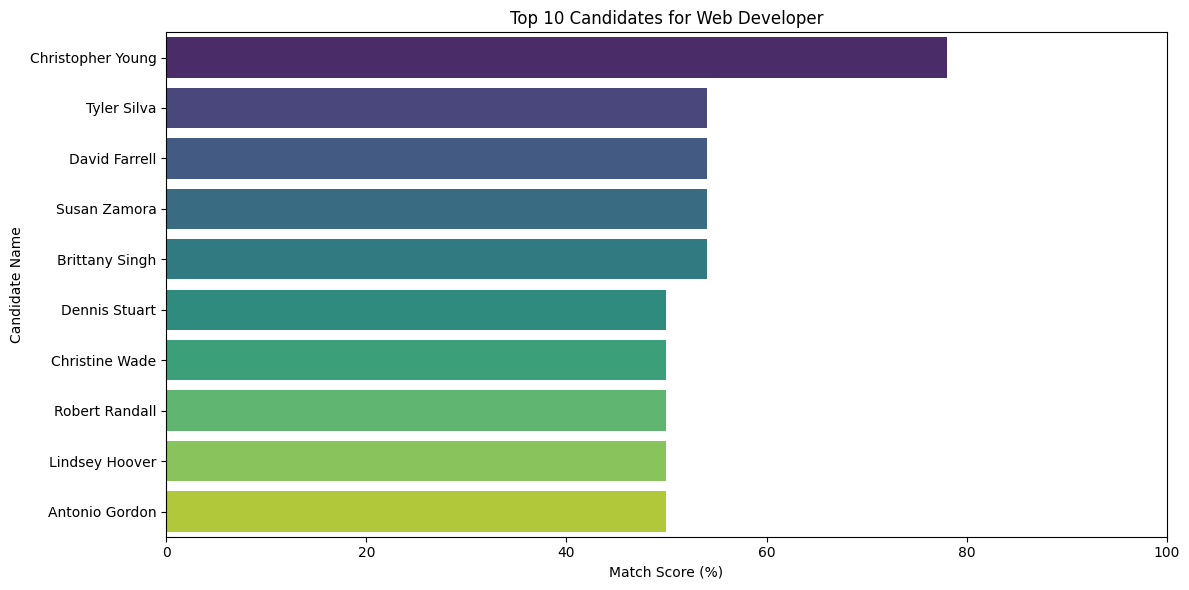

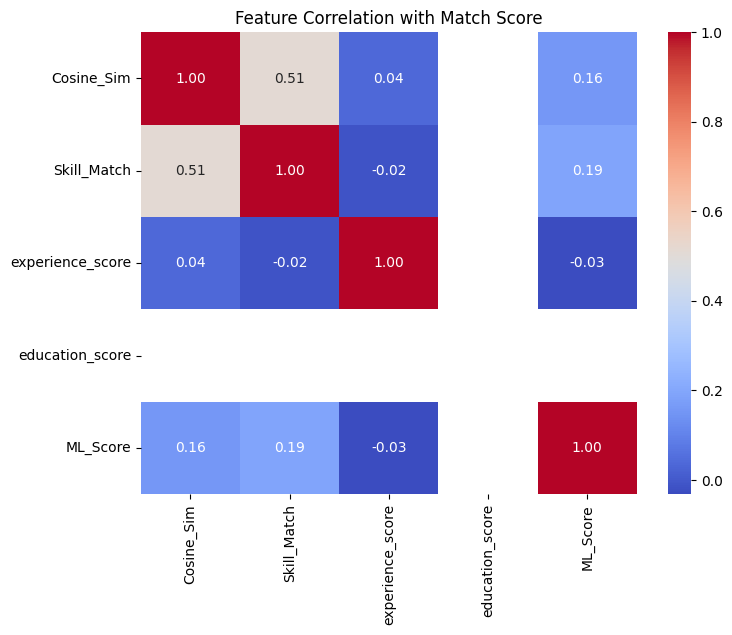

In [7]:
# Step 0: Install packages (only once, if not installed)
# !pip install pandas numpy scikit-learn sentence-transformers matplotlib seaborn

# Step 1: Import Libraries
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import resample

# Step 2: Load Datasets
resumes = pd.read_csv("resumes_dataset_2000.csv")   # name,email,phone,skills,education,experience_years,current_role
jobs = pd.read_csv("job_descriptions_1000.csv")     # job_id,title,required_skills,min_experience,preferred_education,location,employment_type

# Step 3: User Input - Select Job by Title
print("\nAvailable Job Roles:")
print(jobs[['job_id', 'title']].sample(10).to_string(index=False))

job_title = input("\nEnter the Job Title to rank candidates: ").strip().lower()
job_row = jobs[jobs['title'].str.lower() == job_title]

if job_row.empty:
    raise ValueError(f"Job Title '{job_title}' not found.")
job = job_row.iloc[0]
job_id = job['job_id']

# Step 4: Extract Job Attributes
required_skills = [s.strip() for s in str(job['required_skills']).split(",") if s.strip()]
preferred_edu = job.get('preferred_education', 'B.Tech')
min_exp = job.get('min_experience', 1)

# Step 5: Preprocess Resumes
resumes['Skills_List'] = resumes['skills'].apply(lambda x: [s.strip() for s in str(x).split(",") if s.strip()])

# Step 6: Compute Embeddings & Cosine Similarity
model = SentenceTransformer('all-MiniLM-L6-v2')
jd_text = f"{job['title']} {job['required_skills']} {job['preferred_education']}"
jd_emb = model.encode([jd_text])

resumes['Resume_Embedding'] = resumes['skills'].apply(lambda x: model.encode([str(x)])[0])
resumes['Cosine_Sim'] = resumes['Resume_Embedding'].apply(lambda x: cosine_similarity([x], [jd_emb[0]])[0][0])

# Step 7: Skill Match Ratio
def skill_match_ratio(candidate_skills, required_skills):
    matched = len(set([s.lower() for s in candidate_skills]) & set([s.lower() for s in required_skills]))
    return matched / len(required_skills) if required_skills else 0

resumes['Skill_Match'] = resumes['Skills_List'].apply(lambda x: skill_match_ratio(x, required_skills))

# Step 8: Experience Score
resumes['experience_years'] = resumes['experience_years'].fillna(0)
resumes['experience_score'] = resumes['experience_years'].apply(
    lambda x: min(x / min_exp, 1) if min_exp > 0 else 1
)

# Step 9: Education Score
edu_map = {
    'B.E': 0.5, 'B.Tech': 0.5, 'M.E': 0.7, 'M.Tech': 0.7,
    'BSc': 0.5, 'MSc': 0.7, 'BCA': 0.5, 'MCA': 0.7,
    'BBA': 0.5, 'MBA': 0.8, 'PhD': 1.0
}
preferred_score = edu_map.get(preferred_edu, 0.5)
resumes['education_score'] = resumes['education'].map(edu_map).fillna(0.3)
resumes['education_score'] = resumes['education_score'].apply(lambda x: 1.0 if x >= preferred_score else x)

# Step 10: Pseudo Labels (Refined)
def pseudo_label(sim):
    if sim >= 0.8:
        return 1
    elif sim < 0.6:
        return 0
    else:
        return -1  # uncertain

resumes['Label'] = resumes['Cosine_Sim'].apply(pseudo_label)
resumes = resumes[resumes['Label'] != -1]  # remove uncertain cases

# Step 11: Balance Classes
majority = resumes[resumes['Label'] == 1]
minority = resumes[resumes['Label'] == 0]
minority_upsampled = resample(minority, replace=True, n_samples=len(majority), random_state=42)
resumes_balanced = pd.concat([majority, minority_upsampled])

# Step 12: Train Random Forest Model
features = ['Cosine_Sim', 'Skill_Match', 'experience_score', 'education_score']
X = resumes_balanced[features]
y = resumes_balanced['Label']

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

resumes['ML_Score'] = rf.predict_proba(resumes[features])[:, 1]
resumes['ML_Score_Percent'] = resumes['ML_Score'] * 100

# Step 13: Rank Top 10 Candidates
top_resumes = resumes.sort_values(by='ML_Score', ascending=False).head(10)

print(f"\n📌 Top 10 Ranked Resumes for Job Title: {job['title']} (Job ID: {job_id})")
print(top_resumes[['name','email','phone','Cosine_Sim','Skill_Match','experience_score','education_score','ML_Score_Percent']])

# Step 14: Visualization - Top 10 Barplot
plt.figure(figsize=(12, 6))
sns.barplot(x='ML_Score_Percent', y='name', data=top_resumes, palette='viridis')
plt.xlabel("Match Score (%)")
plt.ylabel("Candidate Name")
plt.title(f"Top 10 Candidates for {job['title']}")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

# Step 15: Visualization - Feature Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(resumes[features + ['ML_Score']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation with Match Score")
plt.show()

Available Job Roles:
1. Backend Developer
2. IT Support Specialist
3. Frontend Developer
4. AI Engineer
5. Project Manager
6. Web Developer
7. Database Administrator
8. Product Manager
9. Machine Learning Engineer
10. Full Stack Developer
11. Systems Analyst
12. DevOps Engineer
13. Data Scientist
14. Cloud Engineer
15. Cybersecurity Analyst


c:\Users\Gnanendhiran V\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)



📌 Top 10 Candidates for 'Cloud Engineer' Role:
                     name                         email  Cosine_Sim  \
1986       Jeffrey Barber  sullivancristian@example.org    0.557210   
1987          Daniel Horn      kathrynclark@example.com    0.654021   
1992      Karen Zimmerman         charles36@example.com    0.504026   
22    Christina Henderson      whitakercory@example.net    0.592855   
25        Kimberly Franco          denise62@example.org    0.616631   
28        Dean Stephenson         natasha32@example.org    0.686133   
29         Matthew Mccann  daughertyjessica@example.net    0.516725   
1952  Mr. Raymond Orr Jr.       michaelmary@example.org    0.512542   
1953     Mr. David Kramer            jpoole@example.net    0.535447   
1957         Jason Rogers           wendy92@example.net    0.547957   

      ML_Score_Percent  
1986             100.0  
1987             100.0  
1992             100.0  
22               100.0  
25               100.0  
28               100

C:\Users\Gnanendhiran V\AppData\Local\Temp\ipykernel_14344\880785867.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='ML_Score_Percent', y='name', data=top_resumes, palette='viridis')


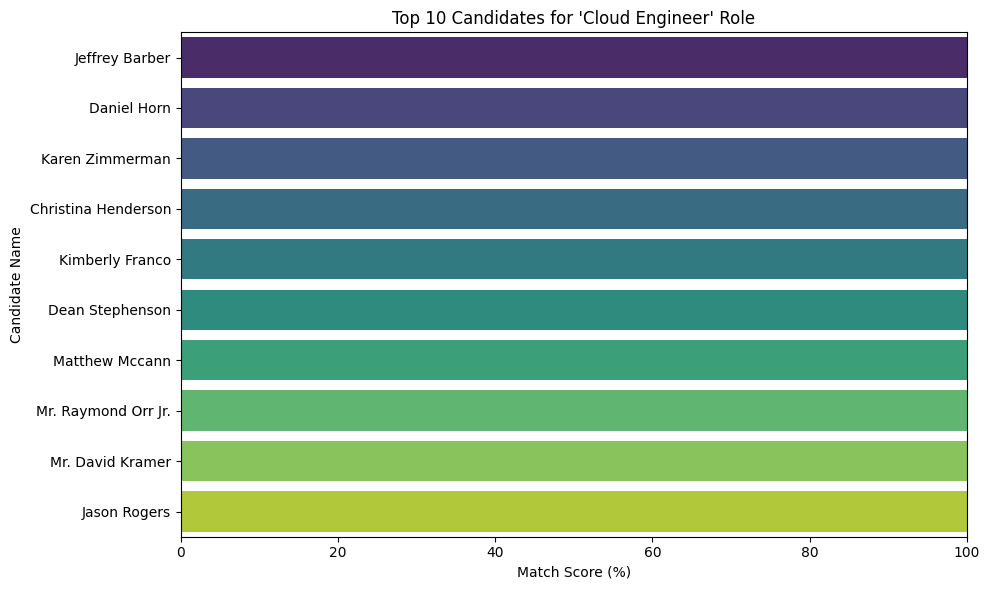


📌 Skill Gap Analysis for Top 10 Candidates:
                     name                         email  \
1986       Jeffrey Barber  sullivancristian@example.org   
1987          Daniel Horn      kathrynclark@example.com   
1992      Karen Zimmerman         charles36@example.com   
22    Christina Henderson      whitakercory@example.net   
25        Kimberly Franco          denise62@example.org   
28        Dean Stephenson         natasha32@example.org   
29         Matthew Mccann  daughertyjessica@example.net   
1952  Mr. Raymond Orr Jr.       michaelmary@example.org   
1953     Mr. David Kramer            jpoole@example.net   
1957         Jason Rogers           wendy92@example.net   

                                     Missing_Skills  
1986         [Express, JavaScript, Computer Vision]  
1987                     [Express, Computer Vision]  
1992           [Flask, JavaScript, Computer Vision]  
22                                 [Flask, Express]  
25                              [Fl

C:\Users\Gnanendhiran V\AppData\Local\Temp\ipykernel_14344\880785867.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Missing_Skills_Count', y='name', data=top_resumes, palette='magma')


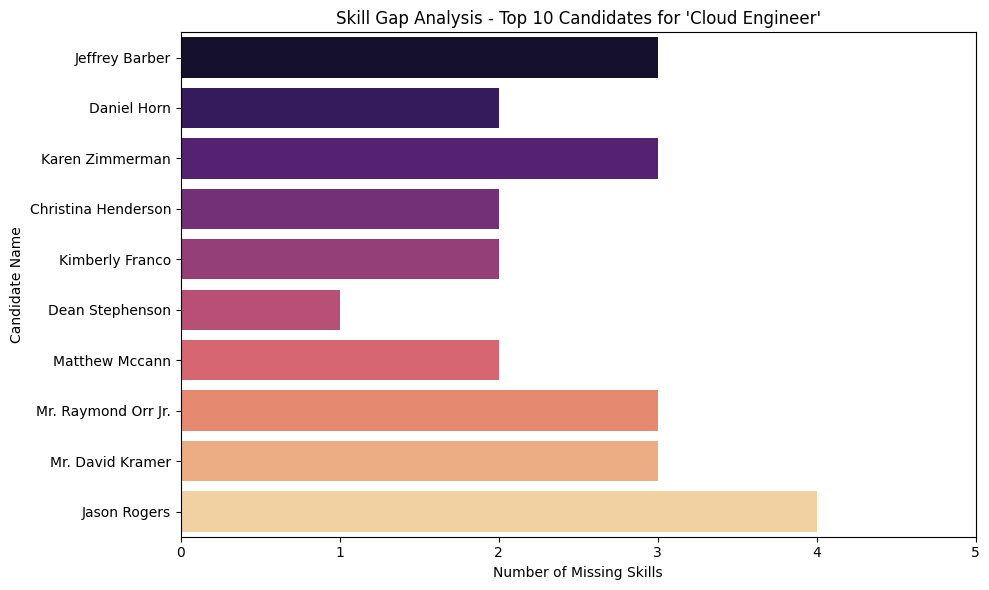

In [8]:
# Step 0: Install packages if not installed
# !pip install pandas numpy scikit-learn sentence-transformers matplotlib seaborn

# Step 1: Import Libraries
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Load Datasets
resumes = pd.read_csv("resumes_dataset_2000.csv")
jobs = pd.read_csv("job_descriptions_1000.csv")

# Step 3: Display all job roles vertically
print("Available Job Roles:")
for idx, role in enumerate(jobs['title'].drop_duplicates(), 1):
    print(f"{idx}. {role}")

# Step 4: Get user input
job_title_input = input("\nEnter the Job Role to rank candidates: ").strip()
job_row = jobs[jobs['title'].str.lower() == job_title_input.lower()]
if job_row.empty:
    raise ValueError(f"No job found with role '{job_title_input}'")
job = job_row.iloc[0]

# Step 5: Extract job attributes
required_skills = [s.strip() for s in str(job['required_skills']).split(",") if s.strip()]
preferred_edu = job.get('preferred_education', 'B.Tech')
min_exp = job.get('min_experience', 1)

# Step 6: Preprocess resumes
resumes['Skills_List'] = resumes['skills'].apply(lambda x: [s.strip() for s in str(x).split(",") if s.strip()])

# Step 7: Compute embeddings & Cosine Similarity
model = SentenceTransformer('all-MiniLM-L6-v2')
jd_text = f"{job['title']} {job['required_skills']} {job['preferred_education']}"
jd_emb = model.encode([jd_text])

resumes['Resume_Embedding'] = resumes['skills'].apply(lambda x: model.encode([str(x)])[0])
resumes['Cosine_Sim'] = resumes['Resume_Embedding'].apply(lambda x: cosine_similarity([x], [jd_emb[0]])[0][0])

# Step 8: Skill Match Ratio
def skill_match_ratio(candidate_skills, required_skills):
    matched = len(set([s.lower() for s in candidate_skills]) & set([s.lower() for s in required_skills]))
    return matched / len(required_skills) if required_skills else 0

resumes['Skill_Match'] = resumes['Skills_List'].apply(lambda x: skill_match_ratio(x, required_skills))

# Step 9: Experience & Education Score
resumes['experience_years'] = resumes['experience_years'].fillna(0)
resumes['experience_score'] = resumes['experience_years'].apply(lambda x: min(x / min_exp, 1) if min_exp > 0 else 1)

edu_map = {'B.E':0.5,'B.Tech':0.5,'M.E':0.7,'M.Tech':0.7,'BSc':0.5,'MSc':0.7,'BCA':0.5,'MCA':0.7,'BBA':0.5,'MBA':0.8,'PhD':1.0}
preferred_score = edu_map.get(preferred_edu, 0.5)
resumes['education_score'] = resumes['education'].map(edu_map).fillna(0.3)
resumes['education_score'] = resumes['education_score'].apply(lambda x: 1.0 if x >= preferred_score else x)

# Step 10: Pseudo labels for weak supervision
def pseudo_label(sim):
    if sim >= 0.75: return 1
    elif sim < 0.5: return 0
    else: return 1

resumes['Label'] = resumes['Cosine_Sim'].apply(pseudo_label)

# Step 11: Train Random Forest Model
features = ['Cosine_Sim','Skill_Match','experience_score','education_score']
X = resumes[features]
y = resumes['Label']

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

resumes['ML_Score'] = rf.predict_proba(X)[:,1]
resumes['ML_Score_Percent'] = resumes['ML_Score']*100

# Step 12: Display Top 10 Candidates
top_resumes = resumes.sort_values(by='ML_Score', ascending=False).head(10)
print(f"\n📌 Top 10 Candidates for '{job['title']}' Role:")
print(top_resumes[['name','email','Cosine_Sim','ML_Score_Percent']])

# Step 13: Visualization - Bar Chart
plt.figure(figsize=(10,6))
sns.barplot(x='ML_Score_Percent', y='name', data=top_resumes, palette='viridis')
plt.xlabel("Match Score (%)")
plt.ylabel("Candidate Name")
plt.title(f"Top 10 Candidates for '{job['title']}' Role")
plt.xlim(0,100)
plt.tight_layout()
plt.show()

# Step 14: Skill Gap Analysis
def missing_skills(candidate_skills, required_skills):
    return [skill for skill in required_skills if skill.lower() not in [s.lower() for s in candidate_skills]]

top_resumes['Missing_Skills'] = top_resumes['Skills_List'].apply(lambda x: missing_skills(x, required_skills))
print("\n📌 Skill Gap Analysis for Top 10 Candidates:")
print(top_resumes[['name','email','Missing_Skills']])
# Step 15: Skill Gap Visualization
top_resumes['Missing_Skills_Count'] = top_resumes['Missing_Skills'].apply(len)

plt.figure(figsize=(10,6))
sns.barplot(x='Missing_Skills_Count', y='name', data=top_resumes, palette='magma')
plt.xlabel("Number of Missing Skills")
plt.ylabel("Candidate Name")
plt.title(f"Skill Gap Analysis - Top 10 Candidates for '{job['title']}'")
plt.xlim(0, max(top_resumes['Missing_Skills_Count'])+1)
plt.tight_layout()
plt.show()

